#Spatial Inequality in Access to Community Health Clinics Across Chicago

##Introduction

Chicago has long experienced major inequalities in healthcare access that are closely tied to patterns of segregation, income inequality, and uneven urban development. Community health clinics, particularly Federally Qualified Health Centers (FQHCs), play an important role in providing affordable primary care services to underserved populations, including low-income residents, uninsured individuals, immigrants, refugees, and youth. Understanding where these clinics are located can provide insight into how healthcare resources are distributed across the city and whether certain neighborhoods may still face barriers to access.

This project uses geospatial analysis to examine the distribution of community health clinics across Chicago community areas. Using clinic location data containing addresses, geographic coordinates, and clinic classifications, a spatial dataset was created and mapped using GeoPandas. The project investigates whether clinics appear evenly distributed throughout the city or whether they cluster in particular neighborhoods and corridors.


In [ ]:
!pip install Census
!pip install us

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from census import Census
from us import states
from shapely.geometry import Point

clinics = pd.read_csv("/content/Clinics.csv")

In [ ]:
clinics.columns = [
    "clinic_name",
    "community_area",
    "phone",
    "clinic_notes",
    "address_raw"
]
clinics["community_area_num"] = clinics["community_area"].str.extract(r"\((\d+)\)")
clinics["community_area_name"] = clinics["community_area"].str.extract(r"^(.*?)\s*\(")
clinics["latitude"] = clinics["address_raw"].str.extract(r"\(([-\d\.]+),")
clinics["longitude"] = clinics["address_raw"].str.extract(r",\s*([-\d\.]+)\)")
clinics["latitude"] = pd.to_numeric(clinics["latitude"], errors="coerce")
clinics["longitude"] = pd.to_numeric(clinics["longitude"], errors="coerce")
clinics["zip"] = clinics["address_raw"].str.extract(r"(\d{5})")
clinics["address"] = (
    clinics["address_raw"]
    .str.replace(r"\(.*?\)", "", regex=True)
    .str.replace(r"\d{5}", "", regex=True)
    .str.replace(r"\n", " ", regex=True)
    .str.strip()
)

def classify_clinic(x):
    x = str(x).lower()

    if "fqhc" in x:
        return "FQHC"
    elif "look-alike" in x:
        return "Look-alike"
    else:
        return "Other"

clinics["clinic_type"] = clinics["clinic_notes"].apply(classify_clinic)

clinics = clinics.drop_duplicates()
clinics.to_csv("clinics.csv", index=False)

In [ ]:
clinics

,clinic_name,community_area,phone,clinic_notes,address_raw,community_area_num,community_area_name,latitude,longitude,zip,address,clinic_type
0,Mercy Family Health Center @ Oakwood Shores,OAKLAND (36),(773) 451-0460,Look-alike,3753 S. Cottage Grove60653\n(41.82672248000045...,36,OAKLAND,41.826722,-87.608287,60653,3753 S. Cottage Grove,Look-alike
1,ACCESS Southwest Family Health Center,GARFIELD RIDGE (56),(866) 882-2237,FQHC,"4839 W. 47th Street60638\n(41.80757461200045, ...",56,GARFIELD RIDGE,41.807575,-87.744602,60638,4839 W. 47th Street,FQHC
2,Heartland Health Outreach- Refugee Health,UPTOWN (3),(773) 751-1744,FQHC; specialize in refugee health,"4750 N Sheridan Rd60640\n(41.96843068300046, -...",3,UPTOWN,41.968431,-87.654857,60640,4750 N Sheridan Rd,FQHC
3,Heartland Health Center- Hibbard Elementary Sc...,ALBANY PARK (14),(773) 336-6100,FQHC; School-based health center (open to comm...,4930 North Sawyer Avenue60625\n(41.97084703000...,14,ALBANY PARK,41.970847,-87.709774,60625,4930 North Sawyer Avenue,FQHC
4,Near North - Winfield Moody Health Center,NEAR NORTH SIDE (8),(312) 337-1073,FQHC,"1276 N. Clybourn60610\n(41.90535451700049, -87...",8,NEAR NORTH SIDE,41.905355,-87.641786,60610,1276 N. Clybourn,FQHC
...,...,...,...,...,...,...,...,...,...,...,...,...
115,Mercy Family Health Center @ Mercy Hospital,NEAR SOUTH SIDE (33),(312) 567-2000,Look-alike,"2525 S. Michigan60616\n(41.846811956000465, -8...",33,NEAR SOUTH SIDE,41.846812,-87.623523,60616,2525 S. Michigan,Look-alike
116,ACCESS Cabrini Family Health Center,MCKINLEY PARK (59),(866) 882-2237,FQHC,"3450 S. Archer Ave.60608\n(41.8312221810005, -...",59,MCKINLEY PARK,41.831222,-87.676340,60608,3450 S. Archer Ave.,FQHC
117,Alivio Medical Center -Little Village Lawndale...,SOUTH LAWNDALE (30),(773) 254-1400,FQHC,"3120 S Kostner Ave60623\n(41.83605293800048, -...",30,SOUTH LAWNDALE,41.836053,-87.734068,60623,3120 S Kostner Ave,FQHC
118,UIC - Mile Square - Englewood,ENGLEWOOD (68),(312) 996-2000,FQHC,"641 W. 63rd Street60621\n(41.77979320600048, -...",68,ENGLEWOOD,41.779793,-87.640958,60621,641 W. 63rd Street,FQHC


<Axes: >

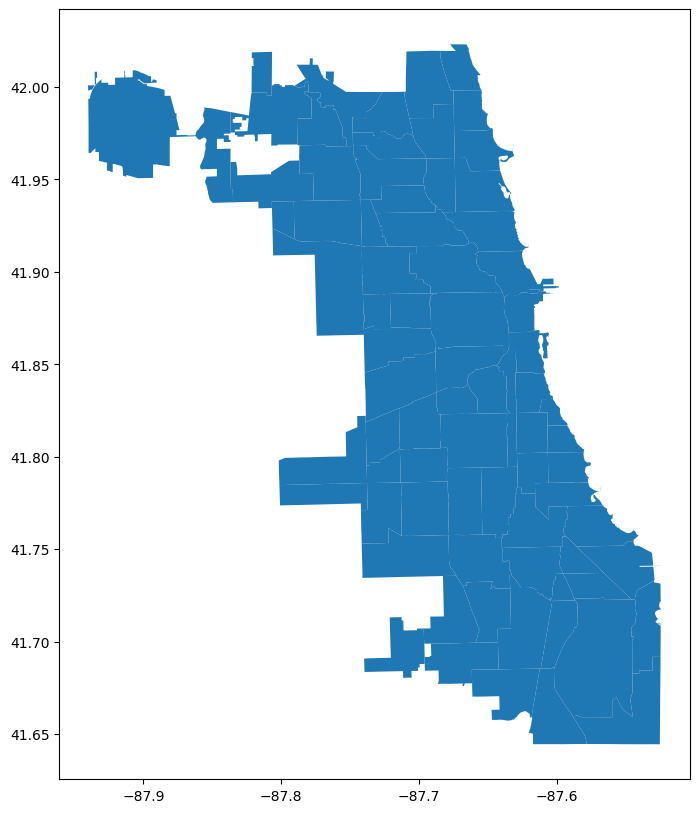

In [ ]:
geometry = gpd.points_from_xy(clinics["longitude"], clinics["latitude"])

gdf = gpd.GeoDataFrame(
    clinics,
    geometry=geometry,
    crs="EPSG:4326"
)
gdf = gdf[
    (gdf["longitude"] > -89) &
    (gdf["longitude"] < -87) &
    (gdf["latitude"] > 41) &
    (gdf["latitude"] < 42.5)
]
community_areas = gpd.read_file(
    "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"
)
community_areas.plot(figsize=(10,10))

<Axes: >

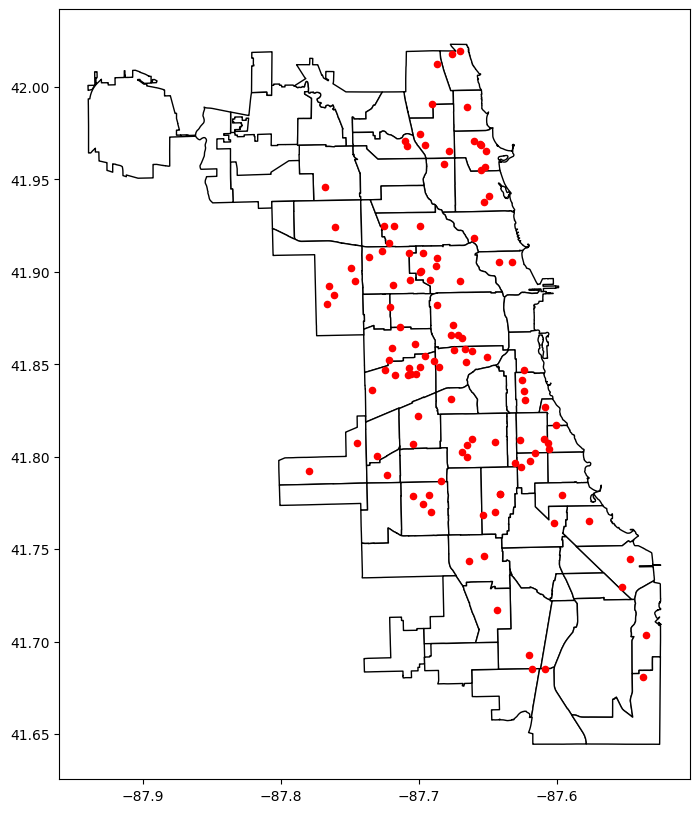

In [ ]:
ax = community_areas.plot(
    figsize=(10,10),
    color="white",
    edgecolor="black"
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=20
)

##Research Question 1: Are community health clinics distributed according to neighborhood need across Chicago?

Previous research has found that community health resources in Chicago are unevenly distributed across neighborhoods. Kim et al. argue that “not all disadvantaged neighborhoods equally benefit from such programs.” This project explores whether community health clinic locations in Chicago appear to align with neighborhood socioeconomic need, particularly poverty levels and racial composition. Using census demographic data and geospatial mapping, this analysis investigates whether clinics are concentrated in the neighborhoods with the greatest disadvantage or whether some high-need areas remain underserved.

In [ ]:
c = Census("54240400e7f28af6d8247ba6ad58f9b60cf1e345")
acs = c.acs5.state_county_tract(
    fields = (
        'NAME',
        'B19013_001E',
        'B17001_002E',
        'B01003_001E',
        'B02001_003E',
        'B02001_002E',
        'B03003_003E'
    ),
    state_fips=states.IL.fips,
    county_fips='031',
    tract='*',
    year=2022
)

acs_df = pd.DataFrame(acs)
acs_df = acs_df.rename(columns={
    "B19013_001E": "median_income",
    "B17001_002E": "poverty_population",
    "B01003_001E": "total_population",
    "B02001_003E": "black_population",
    "B02001_002E": "white_population",
    "B03003_003E": "hispanic_population"
})

acs_df["pct_black"] = (
    acs_df["black_population"] /
    acs_df["total_population"]
) * 100

acs_df["pct_poverty"] = (
    acs_df["poverty_population"] /
    acs_df["total_population"]
) * 100

acs_df["pct_hispanic"] = (
    acs_df["hispanic_population"] /
    acs_df["total_population"]
) * 100

acs_df["GEOID"] = (
    acs_df["state"] +
    acs_df["county"] +
    acs_df["tract"]
)
tracts = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2022/TRACT/tl_2022_17_tract.zip"
)
tracts = tracts[
    tracts["COUNTYFP"] == "031"
]
tracts = tracts.merge(
    acs_df,
    on="GEOID",
    how="left"
)

In [ ]:
community_areas = gpd.read_file(
    "https://raw.githubusercontent.com/RandomFractals/ChicagoCrimes/master/data/chicago-community-areas.geojson"
)
tracts = tracts.to_crs(community_areas.crs)
tracts_joined = gpd.sjoin(
    tracts,
    community_areas,
    predicate="intersects"
)
community_demo = (
    tracts_joined
    .groupby("community")
    .agg({
        "total_population": "sum",
        "black_population": "sum",
        "hispanic_population": "sum",
        "poverty_population": "sum"
    })
    .reset_index()
)
community_demo["pct_black"] = (
    community_demo["black_population"] /
    community_demo["total_population"]
) * 100

community_demo["pct_hispanic"] = (
    community_demo["hispanic_population"] /
    community_demo["total_population"]
) * 100

community_demo["pct_poverty"] = (
    community_demo["poverty_population"] /
    community_demo["total_population"]
) * 100
clinic_counts = (
    gdf.groupby("community_area_name")
    .size()
    .reset_index(name="clinic_count")
)
final = community_demo.merge(
    clinic_counts,
    left_on="community",
    right_on="community_area_name",
    how="left"
)
community_areas = community_areas.merge(
    final,
    on="community",
    how="left"
)

(np.float64(-87.96091293145491),
 np.float64(-87.50333825496381),
 np.float64(41.625618348273974),
 np.float64(42.041963359379665))

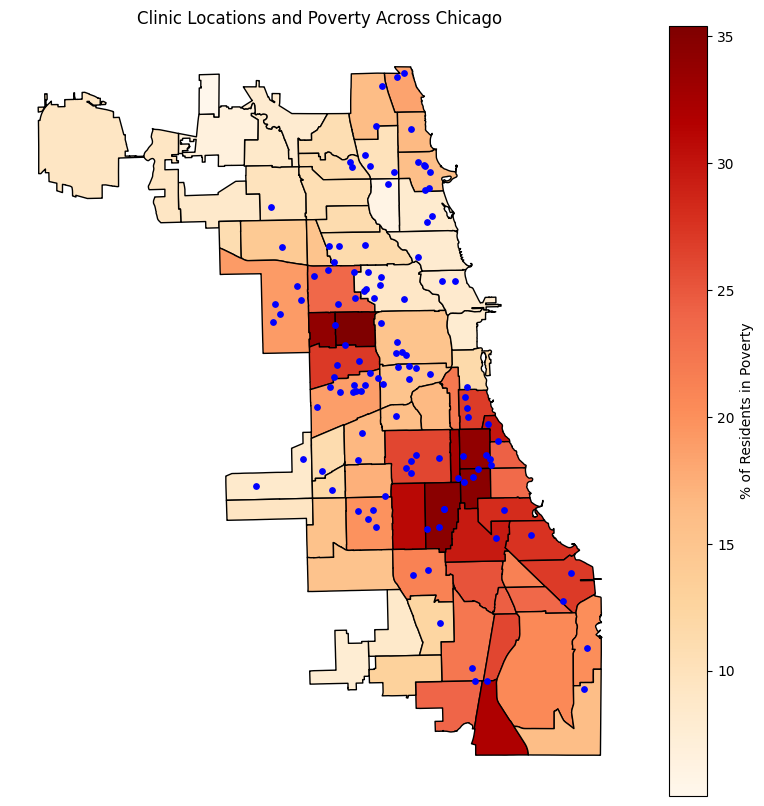

In [ ]:
ax = community_areas.plot(
    column="pct_poverty",
    cmap="OrRd",
    legend=True,
    figsize=(10,10),
    edgecolor="black",
    legend_kwds={"label": "% of Residents in Poverty"}
)

gdf.plot(
    ax=ax,
    color="blue",
    markersize=15
)

plt.title("Clinic Locations and Poverty Across Chicago")
plt.axis("off")

The spatial distribution of clinics appears related to neighborhood poverty levels. Higher-poverty areas on Chicago’s South and West sides generally contain greater concentrations of community health clinics. However, the relationship is not perfectly proportional, as several high-poverty neighborhoods still appear to have relatively limited clinic access compared to surrounding areas.

Although census tracts provide more spatially detailed demographic information, the clinic dataset was organized by Chicago community areas. To ensure that the geographic units aligned across datasets, tract-level ACS demographic data were aggregated to the community-area level before analysis. This allowed clinic counts and neighborhood demographic characteristics to be compared consistently across the same spatial units.

## Research Question 2: Which Chicago neighborhoods appear underserved by community health clinics despite high levels of disadvantage?

Previous research found substantial gaps in access to Chicago’s safety net healthcare system, estimating that more than 300,000 medically needy residents did not receive care from community-based providers (Chicago Department of Public Health, 2005). This suggests that clinic availability may not always align with neighborhood disadvantage. This section explores whether some Chicago neighborhoods with high poverty levels and large minority populations still appear underserved by community health clinics.

In [ ]:
clinic_counts = (
    clinics.groupby("community_area_name")
    .size()
    .reset_index(name="clinic_count")
)

clinic_counts.head()

,community_area_name,clinic_count
0,ALBANY PARK,2
1,ARCHER HEIGHTS,1
2,AUBURN GRESHAM,2
3,AUSTIN,5
4,BELMONT CRAGIN,1


In [ ]:
community_stats = (
    clinics.groupby("community_area_name")
    .agg({
        "community_area_num": "first"
    })
    .reset_index()
)

community_stats["community_area_num"] = pd.to_numeric(
    community_stats["community_area_num"],
    errors="coerce"
)

In [ ]:
community_areas["area_numbe"] = pd.to_numeric(
    community_areas["area_numbe"],
    errors="coerce"
)

In [ ]:
community_map = community_areas.merge(
    clinic_counts,
    left_on="community",
    right_on="community_area_name",
    how="left"
)

In [ ]:
community_map = community_map.rename(
    columns={"clinic_count_y": "clinic_count"}
)

community_map["clinic_count"] = (
    community_map["clinic_count"]
    .fillna(0)
)

In [ ]:
community_map = community_map.drop(
    columns=[
        "clinic_count_x",
        "community_area_name_x",
        "community_area_name_y"
    ]
)

In [ ]:
community_map.head()

,community,area,shape_area,perimeter,area_num_1,area_numbe,comarea_id,comarea,shape_len,geometry,total_population,black_population,hispanic_population,poverty_population,pct_black,pct_hispanic,pct_poverty,clinic_count
0,DOUGLAS,0,46004621.1581,0,35,35,0,0,31027.0545098,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ...",41382.0,23620.0,1891.0,11155.0,57.077957,4.569620,26.956165,3.0
1,OAKLAND,0,16913961.0408,0,36,36,0,0,19565.5061533,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ...",26032.0,22109.0,991.0,7746.0,84.930086,3.806853,29.755685,2.0
2,FULLER PARK,0,19916704.8692,0,37,37,0,0,25339.0897503,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4...",20951.0,12650.0,2872.0,6817.0,60.378980,13.708176,32.537826,1.0
3,GRAND BOULEVARD,0,48492503.1554,0,38,38,0,0,28196.8371573,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4...",48669.0,42343.0,2003.0,16553.0,87.001993,4.115556,34.011383,3.0
4,KENWOOD,0,29071741.9283,0,39,39,0,0,23325.1679062,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ...",33684.0,23014.0,1235.0,8182.0,68.323240,3.666429,24.290464,2.0


In [ ]:
community_map["clinic_count"] = community_map["clinic_count"].fillna(0)

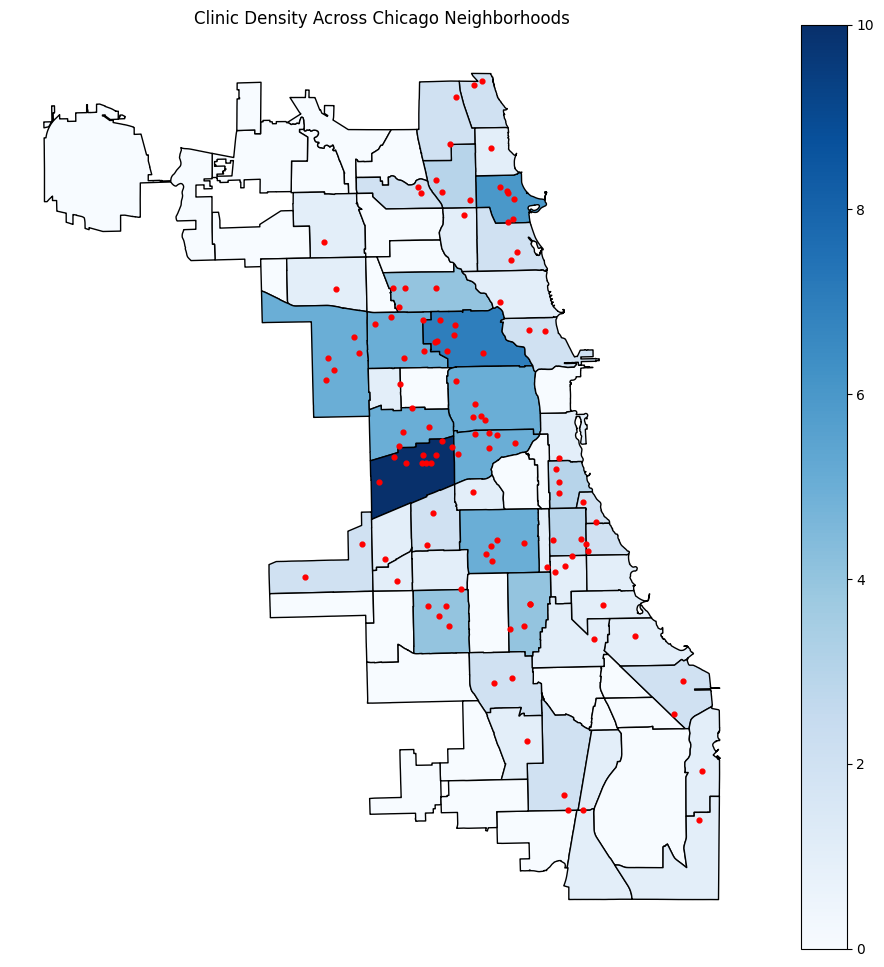

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

community_map.plot(
    column="clinic_count",
    cmap="Blues",
    linewidth=1,
    edgecolor="black",
    legend=True,
    ax=ax
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=12
)

plt.title("Clinic Density Across Chicago Neighborhoods")
plt.axis("off")
plt.show()

## Interpretation

The map shows that community health clinics are not evenly distributed across Chicago neighborhoods. Areas with darker blue shading contain higher numbers of clinics, while lighter areas contain fewer clinics.

Several neighborhoods on Chicago’s West Side and parts of the South Side appear to have the highest clinic concentrations. These areas are also historically associated with higher poverty rates and larger medically underserved populations.

At the same time, the map suggests that clinic access may still be uneven. Some neighborhoods with relatively high levels of disadvantage appear to contain comparatively fewer clinics than nearby areas. This indicates that the spatial distribution of healthcare resources may not perfectly align with neighborhood need.

The results support previous research suggesting that healthcare safety-net services in Chicago may still reflect broader patterns of racial and socioeconomic inequality.

A noticeable cluster of clinics appears in several central-west neighborhoods, while parts of the far South Side and northwest areas contain relatively few clinic locations. This suggests that geographic accessibility to healthcare may vary substantially depending on neighborhood location.

However, because this analysis uses community areas rather than census tracts, the results should be interpreted as broader neighborhood-level patterns rather than precise block-level measures of healthcare accessibility.

## Research Question 3: Do community health clinics appear more concentrated in neighborhoods with larger Black and Hispanic populations?

Chicago has long experienced racial and spatial segregation, which has shaped patterns of healthcare access across neighborhoods.

Health disparities are “closely linked with social, economic, and/or environmental disadvantage” (Illinois Comprehensive Cancer Control Program, 2022). This section explores whether community health clinics in Chicago appear distributed according to neighborhood need, particularly in areas with higher poverty rates and larger minority populations.

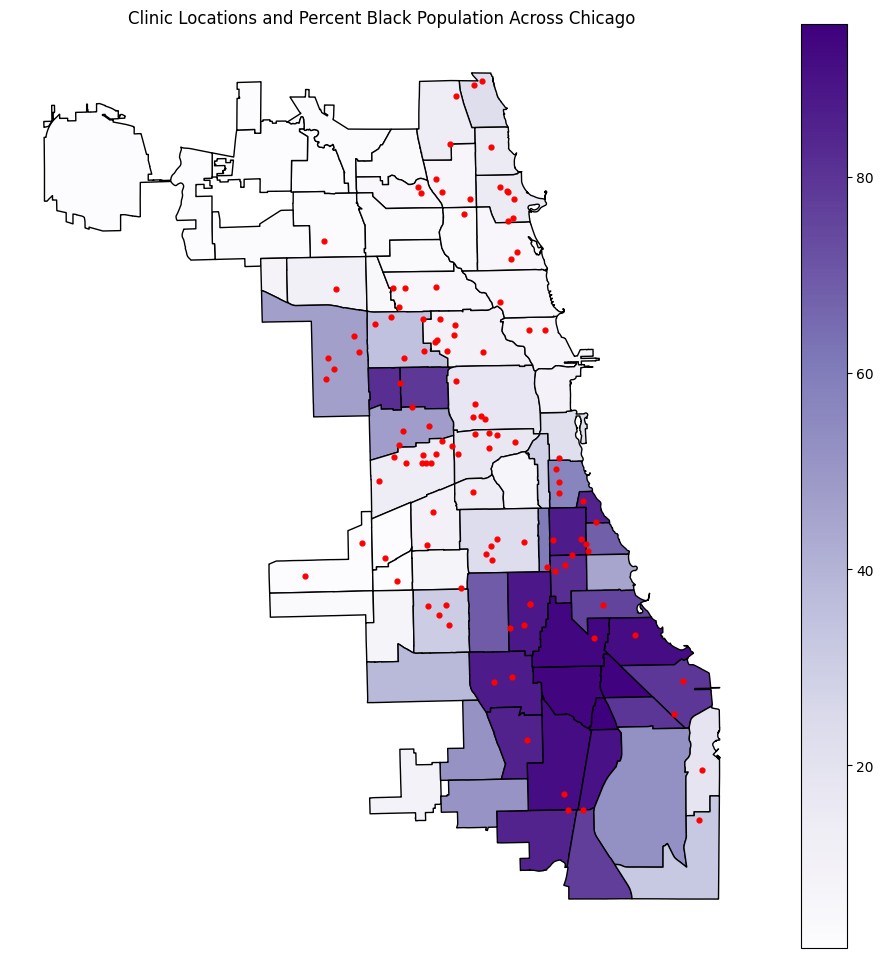

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

community_map.plot(
    column="pct_black",
    cmap="Purples",
    linewidth=1,
    edgecolor="black",
    legend=True,
    ax=ax
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=12
)

plt.title("Clinic Locations and Percent Black Population Across Chicago")
plt.axis("off")
plt.show()

The map shows that many clinics are concentrated in neighborhoods with larger Black populations, particularly on Chicago’s South and West sides. However, the relationship is uneven across neighborhoods. Some predominantly Black areas contain multiple clinics, while others appear to have relatively limited clinic access despite high levels of poverty and demographic disadvantage.

This pattern suggests that the presence of safety-net clinics does not necessarily guarantee equal healthcare access across all predominantly Black communities in Chicago.

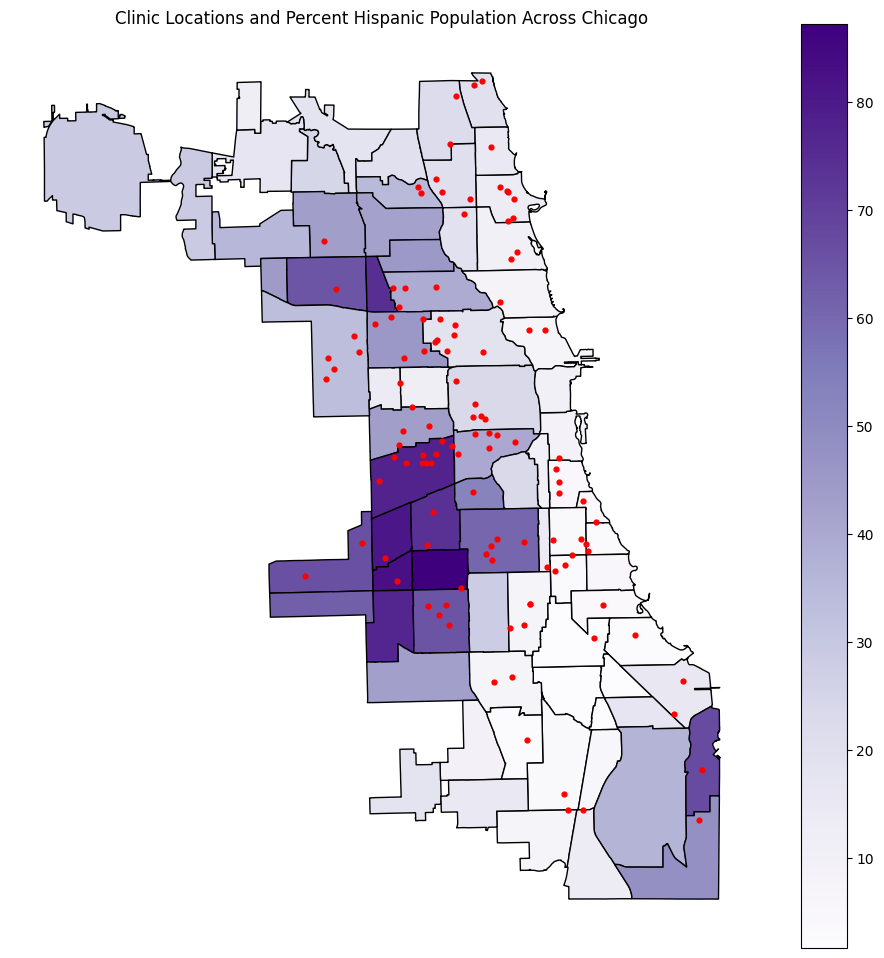

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

community_map.plot(
    column="pct_hispanic",
    cmap="Purples",
    linewidth=1,
    edgecolor="black",
    legend=True,
    ax=ax
)

gdf.plot(
    ax=ax,
    color="red",
    markersize=12
)

plt.title("Clinic Locations and Percent Hispanic Population Across Chicago")
plt.axis("off")
plt.show()

Areas with high percentages of Hispanic residents often contain multiple community clinics, indicating some alignment between healthcare infrastructure and demographic need. However, the distribution is uneven, as certain neighborhoods with large Hispanic populations still appear underserved relative to neighboring areas with higher clinic density.

##References

Chicago Department of Public Health. (2005). *Serving Chicago’s underserved: A report on the health care safety net*. Chicago Department of Public Health.

Kim, Y., Byon, H. D., & Yeo, E. (2021). The uneven distribution of medically underserved areas and community health centers in Chicago.

Illinois Comprehensive Cancer Control Program. (2022). Illinois comprehensive cancer control plan 2022–2027.